In [ ]:
!pip install git+https://github.com/Koziev/rusyllab

  Cloning https://github.com/Koziev/rusyllab to /tmp/pip-req-build-blug5cf8
  Running command git clone --filter=blob:none --quiet https://github.com/Koziev/rusyllab /tmp/pip-req-build-blug5cf8
  Resolved https://github.com/Koziev/rusyllab to commit c5d0ea405e9cc8233bd65503c26c0d2ad8b5cb57
  Preparing metadata (setup.py) ... done
  Created wheel for rusyllab: filename=rusyllab-0.0.4-py3-none-any.whl size=16015 sha256=aab27b4789d3319d693e5cfca1ecdbf6d6446e5ad8f28a309833c961b71dccb0
  Stored in directory: /tmp/pip-ephem-wheel-cache-6z4lcwtg/wheels/f7/17/1e/69f8774b65ec0a46e78a7e55589066bebb3a6a8cf609e835fb
Successfully built rusyllab


In [ ]:
import re
import pandas as pd
import numpy as np
import rusyllab
from scipy import stats
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
import tqdm
import os
import matplotlib.pyplot as plt
import seaborn as sns

Строим барплоты для типов ошибки, чтобы отследить различия в количестве ошибок разного типа для взрослых и ребенка

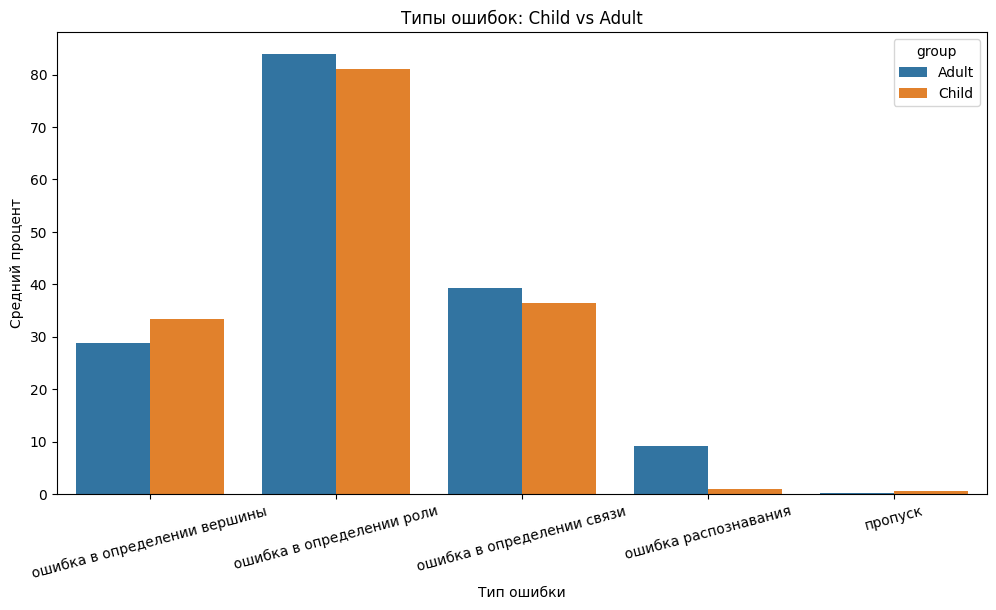

In [ ]:
percent_types = pd.read_csv('types_percents.csv')

error_cols = [
    'ошибка в определении роли',
    'ошибка в определении вершины',
    'ошибка в определении связи',
    'ошибка распознавания',
    'пропуск'
]

plot_df = percent_types[
    percent_types['group'].isin(['Child', 'Adult'])
]

plot_df = plot_df.melt(
    id_vars=['file_id', 'group'],
    value_vars=error_cols,
    var_name='error_type',
    value_name='percent'
)


mean_plot_df = (
    plot_df
    .groupby(['group', 'error_type'])['percent']
    .mean()
    .reset_index()
)

plt.figure(figsize=(12,6))

sns.barplot(
    data=mean_plot_df,
    x='error_type',
    y='percent',
    hue='group'
)

plt.xticks(rotation=15)

plt.xlabel('Тип ошибки')
plt.ylabel('Средний процент')
plt.title('Типы ошибок: Child vs Adult')

plt.savefig(
    'grouped_error_barplot.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

Также строим барплоты для подтипов ошибки

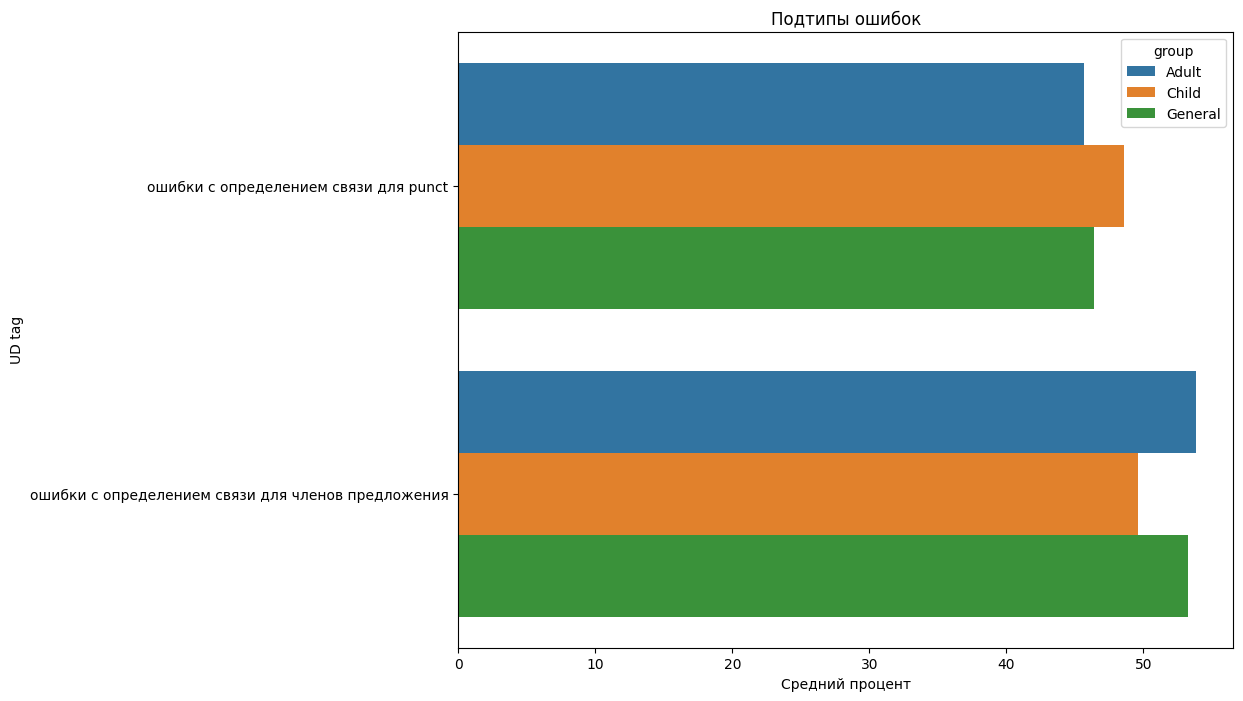

In [ ]:
top10_df = pd.read_csv('error_subtyped_percents.csv')

tag_df = top10_df[
    top10_df['error_class'] == 'punct']

mean_tags = (
    tag_df
    .groupby(['group', 'tag'])['percent_within_class']
    .mean()
    .reset_index()
)

plt.figure(figsize=(10,8))

sns.barplot(
    data=mean_tags,
    y='tag',
    x='percent_within_class',
    hue='group'
)

plt.xlabel('Средний процент')
plt.ylabel('UD tag')

plt.title('Подтипы ошибок')

plt.savefig(
    'punct_errors.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

Строим график распределения процента ошибок по файлам, чтобы проследить динамику во времени

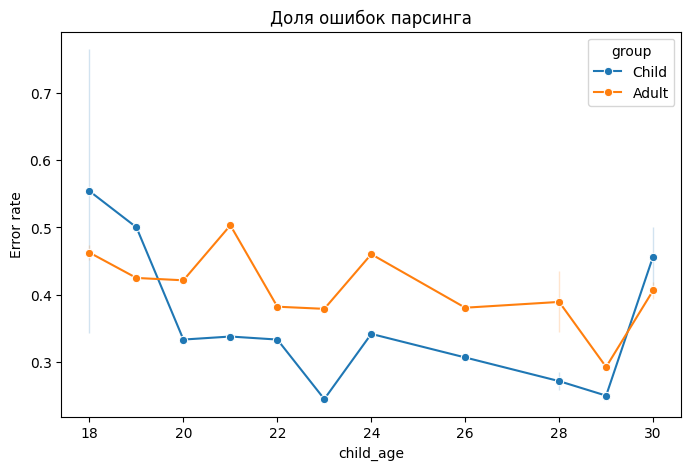

In [ ]:
error_rate_df = pd.read_csv('error_rate with age.csv')

plt.figure(figsize=(8,5))

sns.lineplot(
    data=error_rate_df[
        error_rate_df['group'].isin(['Child', 'Adult'])
    ],
    x='child_age',
    y='error_rate',
    hue='group',
    marker='o'
)

plt.ylabel('Error rate')

plt.title('Доля ошибок парсинга')

plt.savefig(
    'error_rate_by_age.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

In [ ]:
# готоим данные для подсчета количества типов ошибок по месяцам

error_rate_table = (
    error_rate_df[
        error_rate_df['group'].isin(['Child', 'Adult'])
    ]
    .pivot(
        index=['file_id', 'child_age'],
        columns='group',
        values='error_rate'
    )
    .reset_index()
)

error_rate_table.columns = [
    'file_id',
    'child_age',
    'Adult_error_rate',
    'Child_error_rate'
]

error_rate_table.to_csv('error_rate_for_text.csv')

In [ ]:
punct = top10_df[top10_df['error_class'] == 'punct']
synt = top10_df[top10_df['error_class'] == 'tag']

In [ ]:
# типы ошибок для каждого файла

error_cols = [
    'ошибка в определении роли',
    'ошибка в определении вершины',
    'ошибка в определении связи',
    'ошибка распознавания',
    'пропуск'
]

error_types_wide = (
    percent_types[
        percent_types['group'].isin(['Child', 'Adult'])
    ]
    .pivot(
        index='file_id',
        columns='group',
        values=error_cols
    )
)

error_types_wide.columns = [
    f'{group}_{metric}'
    for metric, group in error_types_wide.columns
]

error_types_wide = error_types_wide.reset_index()

error_types_wide.to_csv('error_types_for_text.csv')

In [ ]:
# подтипы ошибок для каждого файла

tag_df = top10_df[
    top10_df['error_class'] == 'punct'
]


tag_wide = (
    tag_df[
        tag_df['group'].isin(['Child', 'Adult'])
    ]
    .pivot_table(
        index='file_id',
        columns=['group', 'tag'],
        values='percent_within_class',
        aggfunc='mean'
    )
)

tag_wide.columns = [
    f'{group}_{tag}'
    for group, tag in tag_wide.columns
]

tag_wide = tag_wide.reset_index()


tag_wide = tag_wide.round(2)

tag_wide.to_csv('subtypes_for_text_punct.csv')

In [ ]:
df = pd.read_csv('error_types_for_text.csv')
df = df.sort_values(['child_age', 'file_id'])

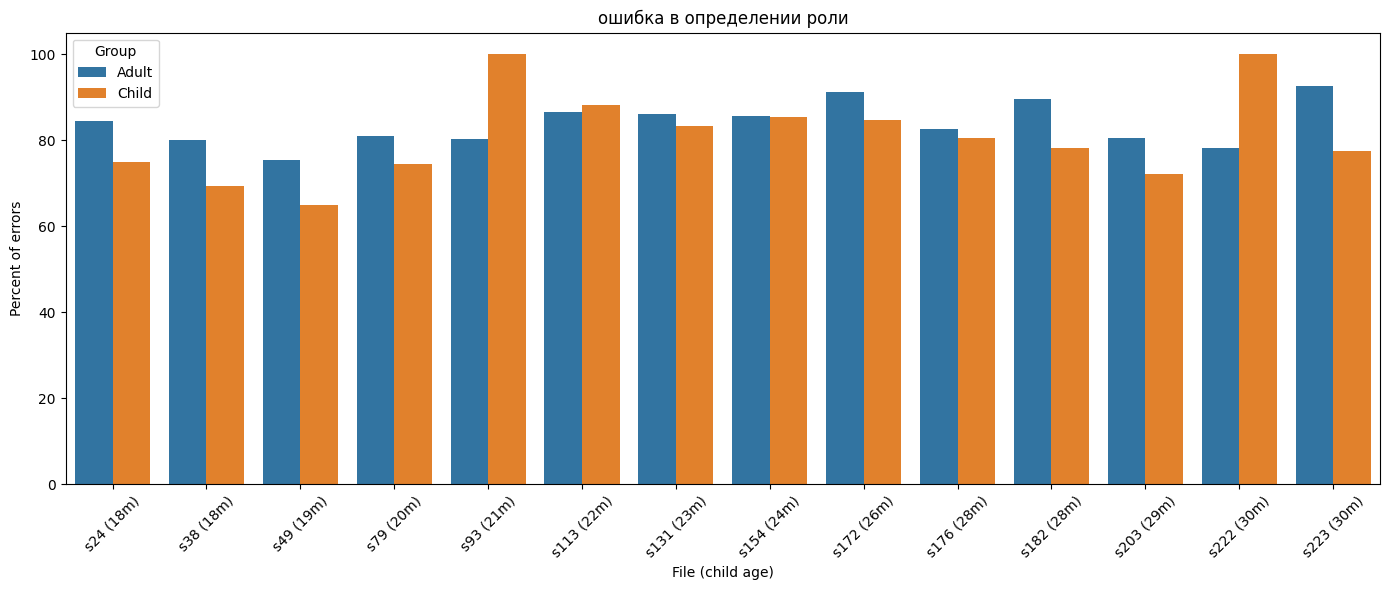

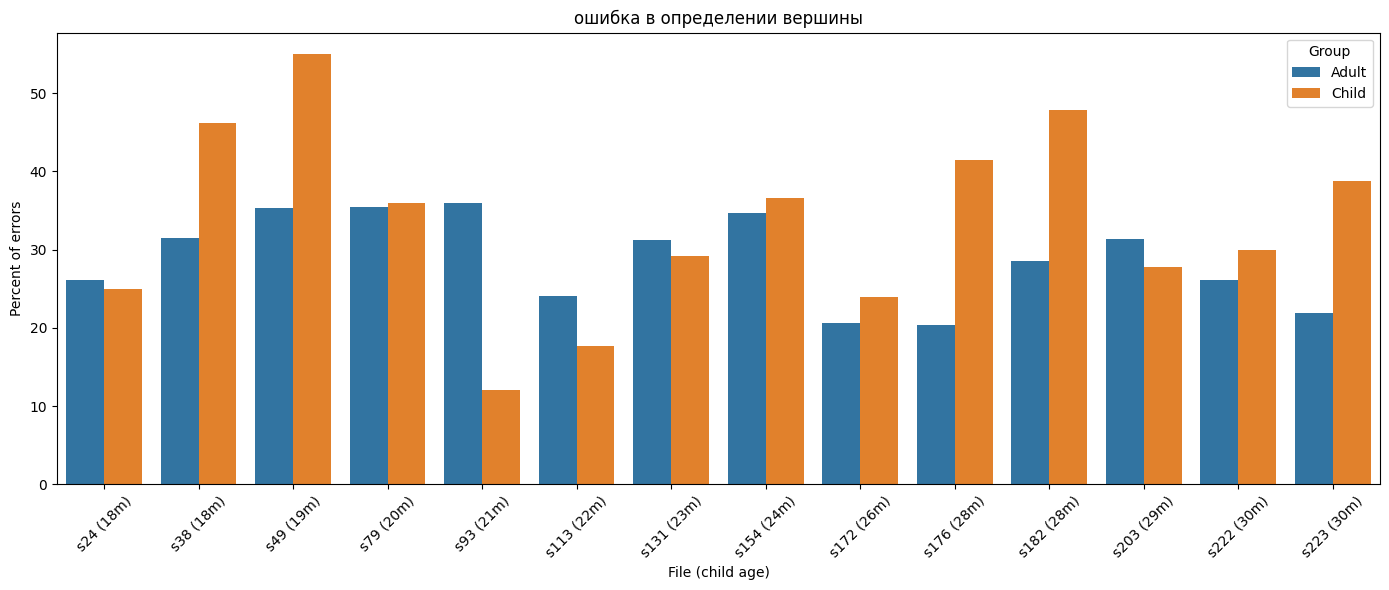

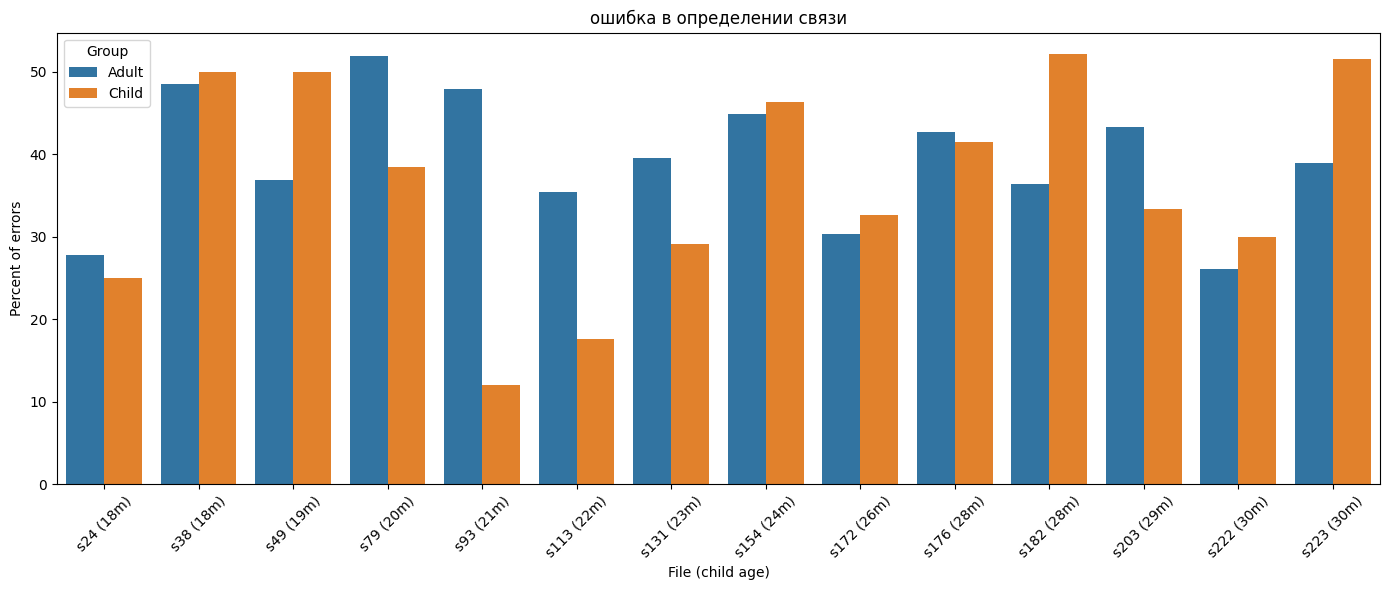

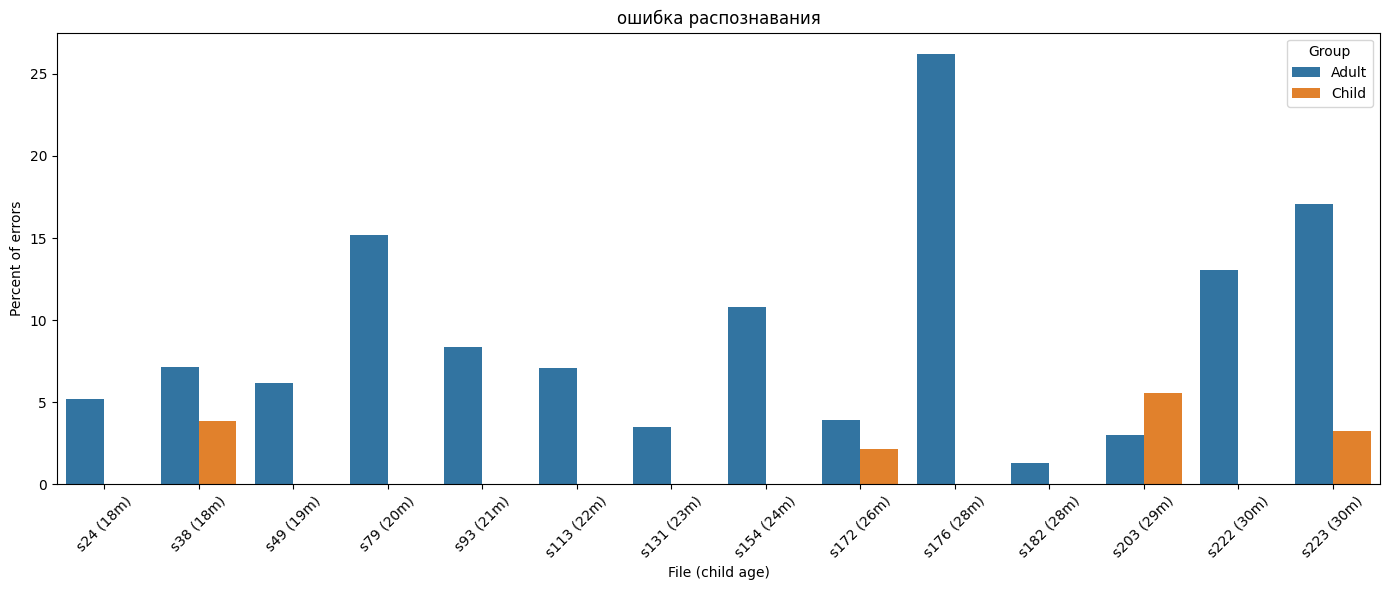

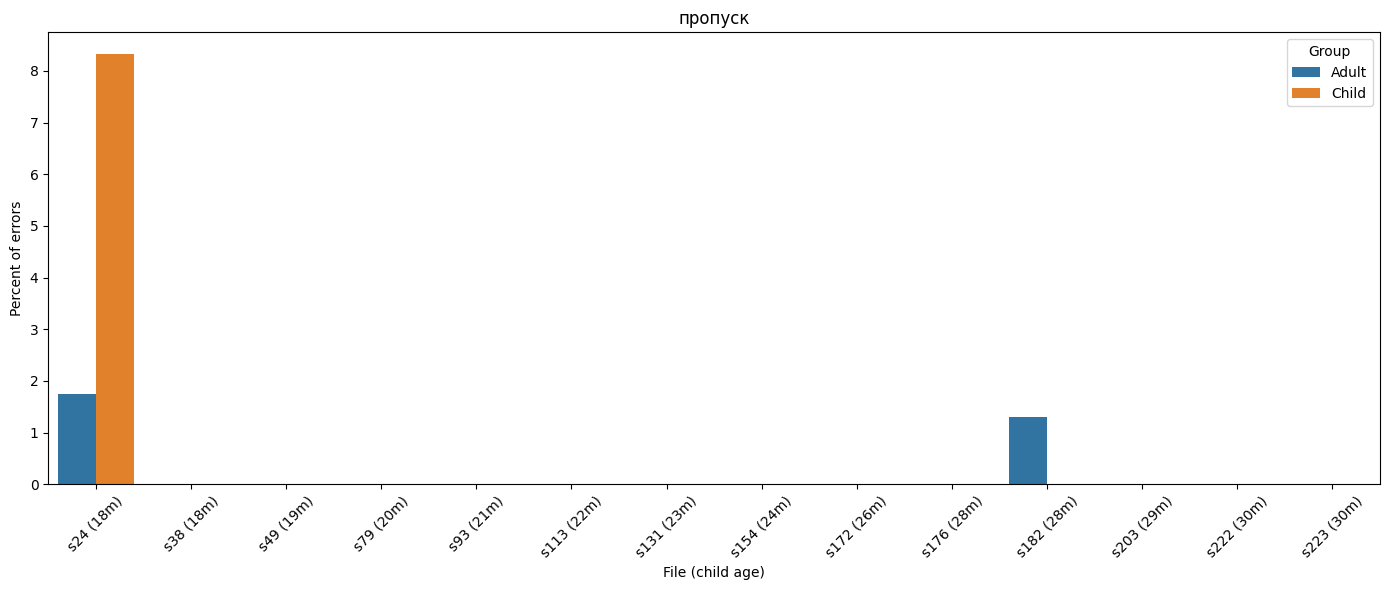

In [ ]:
# строим барплоты для визуализации процентов типов ошибок в каждом файле

error_types = [
    'ошибка в определении роли',
    'ошибка в определении вершины',
    'ошибка в определении связи',
    'ошибка распознавания',
    'пропуск'
]


df['file_label'] = (
    df['file_id'] +
    ' (' +
    df['child_age'].astype(str) +
    'm)'
)

for error in error_types:

    plt.figure(figsize=(14, 6))

    plot_df = pd.DataFrame({
        'file_label': list(df['file_label']) * 2,
        'group': ['Adult'] * len(df) + ['Child'] * len(df),
        'percent': list(df[f'Adult_{error}']) + list(df[f'Child_{error}'])
    })

    sns.barplot(
        data=plot_df,
        x='file_label',
        y='percent',
        hue='group'
    )

    plt.title(error)
    plt.xlabel('File (child age)')
    plt.ylabel('Percent of errors')

    plt.xticks(rotation=45)

    plt.legend(title='Group')

    plt.tight_layout()

    plt.savefig(
        f'{error}_by_file_and_age.png',
        dpi=300,
        bbox_inches='tight'
    )

    plt.show()

In [ ]:
# гоотовим данные по подтипам ошибок для визуализации

df = pd.read_csv('/content/subtypes_for_text.csv')


numeric_df = (
    df.drop(columns='file_id')
      .replace('', np.nan)
      .astype(float)
)


mean_by_error = (
    numeric_df.mean(axis=0)
    .round(2)
    .reset_index()
)

mean_by_error.columns = ['error_type', 'mean_percent']

mean_by_error.to_csv('mean_by_error_type.csv', index=False)

In [ ]:
# фильтруем интересующие нас теги

tags = ['Adult_FLAT', 'Adult_CONJ', 'Adult_OBJ', 'Adult_NSUBJ', 'Adult_VOCATIVE', 'Adult_DISCOURSE',
        'Child_FLAT', 'Child_CONJ', 'Child_OBJ', 'Child_NSUBJ', 'Child_VOCATIVE', 'Child_DISCOURSE']
mean_by_error[mean_by_error['error_type'].isin(tags)]

,error_type,mean_percent
5,Adult_CONJ,11.22
7,Adult_DISCOURSE,43.59
10,Adult_FLAT,10.05
13,Adult_NSUBJ,4.75
15,Adult_OBJ,8.92
20,Adult_VOCATIVE,13.34
27,Child_CONJ,13.57
28,Child_DISCOURSE,19.13
29,Child_FLAT,54.12
30,Child_NSUBJ,7.18


In [ ]:
# строим хитмеп для визуализации частотности неверно распознанных связей

heatmap_df = confusion_df.pivot_table(
    index='gold',
    columns='predicted',
    values='percent_within_gold',
    fill_value=0
)

plt.figure(figsize=(12,8))

sns.heatmap(
    heatmap_df,
    cmap='BuPu'
)

plt.xlabel('Predicted relation')
plt.ylabel('Gold relation')

plt.title('Dependency relation confusions')

plt.savefig(
    'dependency_confusion_heatmap.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()